# V1.6 — Regulator numerical stability (no spurious limit cycles)

**Targets:** protocol §V1.6; Risk: *regulator gain tuning / limit cycles*; ARCHITECTURE Part IV **guardrail #1** ("laws as energies/potentials, not raw forces") and §III.6. **Depends on:** V1.5 (`regulator.py` plant). **Gates:** living-asset work (architecture Phase 2) — V1.6 is the **last** of the two living-asset gates (V1.5 + V1.6).

**Claim (one falsifiable sentence).** Formulating regulator actuation as a **dissipative draw on a bounded reserve (passivity)** prevents spurious **limit-cycle oscillations** across a **strictly wider gain range** than a naïve force-style controller.

**Load-bearing because.** A limit cycle in a steady environment looks like the creature *trembling* — but it is the model *ringing* (a numerical/control artifact), not physiology. If high-gain regulation rings, the living-asset machinery produces motion artifacts mistaken for behaviour. **Nature:** engineering (stability margin). **Failure → outcome:** CONSTRAIN (publish gain bounds + require the passive formulation / sub-stepping).

### The model — the V1.5 plant with an INERTIAL actuator
V1.5's actuator is first-order (`ẋ=(a_target−x)/τ`): a single real pole that *cannot* oscillate. To exhibit (and then suppress) the trembling, the actuator is given **inertia** (second order), so the lagged negative-feedback loop Hopf-bifurcates at high gain. State `(P, x, v)`, `v=ẋ`, at full reserve:
$$\dot P=\mathrm{pump}(P)(1+\beta x)-\gamma P,\quad \dot x=v,\quad \dot v=\omega^2\big(a_{target}(P)-x\big)-d_{eff}\,v,\quad a_{target}=\mathrm{clip}(K(P_{set}-P),0,a_{max}).$$
The two controllers differ **only** in the dissipation: **naïve** `d_eff=d0` (fixed light damping); **passivity** `d_eff=d0+c_d` (extra velocity-proportional dissipation injected by the controller — a draw on the bounded reserve, the energy guardrail).

### Oracle — linear stability analysis vs the nonlinear limit cycle
Linearizing at the healthy fixed point gives the cubic `λ³+(d_eff−a)λ²+(ω²−a·d_eff)λ+ω²(bK−a)` (`a=∂Ṗ/∂P<0`, `b=∂Ṗ/∂x>0`). The **eigenvalues are the independent oracle**: the Hopf gain is where `max Re(λ)=0`. Because `d_eff` is larger under passivity, `K_hopf(passive)>K_hopf(naïve)` — strictly larger by construction. The eigenvalue boundary is judged against the **nonlinear truth**: integrate the full ODE from a small kick and detect a sustained limit cycle (post-transient peak-to-peak of `P` above a floor).

### Pre-registered pass criteria (frozen *before* running; calibrated with margin)
| # | Metric | Threshold | Failure → outcome |
|---|--------|-----------|-------------------|
| **A** | oracle: eigenvalue Hopf gain vs nonlinear limit-cycle onset (naïve) | relative error **≤ 10%** | CONSTRAIN (use nonlinear onset directly) |
| **B** | passivity stable region strictly larger | `K_hopf(passive) ≥ 2× K_hopf(naïve)` **and** 2-D stable-region area(passive) > area(naïve) | CONSTRAIN |
| **C** | production gain envelope | passivity: **0** sustained oscillations across the box; naïve: oscillates at **≥1** point (the hazard is real) | CONSTRAIN (publish gain bounds + sub-stepping) |
| **D** | energy/passivity (support) | actuator storage energy decays under passivity but is sustained under naïve near the Hopf (diagnostic, not a gate) | diagnostic only |

**Expected verdict: PASS** — the passive/energy formulation has a strictly larger oscillation-free gain region, the linear-stability oracle predicts the limit-cycle onset, and within the production envelope the regulated creature does not tremble (while a naïve force controller would). On pass, **V1.5 + V1.6 are both green → architecture Phase 2 (living things) is unblocked** (protocol §9).

In [1]:
"""(1) Setup — imports, frozen pre-registered constants, the inertial regulator model."""
import sys, pathlib
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

REPO = pathlib.Path.cwd()
while not (REPO / "src" / "verification" / "oracles" / "regulator_stability.py").exists():
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "src" / "verification" / "oracles"))
RESULTS = REPO / "verification_notebooks" / "phase1" / "results"

import regulator as rg
import regulator_stability as rs

np.set_printoptions(precision=4, suppress=True)
sp = rs.StabilityParams()                       # frozen: omega=2.0, d0=1.65, c_d=1.5, V1.5 plant

# ---- PRE-REGISTERED constants (frozen after calibration) ----
ORACLE_TOL      = 0.10                           # A: |onset - K_hopf| / K_hopf
KHOPF_RATIO_MIN = 2.0                            # B: K_hopf(passive) / K_hopf(naive)
AMP_FLOOR       = 0.02                           # limit-cycle detection floor (peak-to-peak P)
PROD_GAIN       = 2.0                            # representative production loop gain
K_GRID  = np.linspace(0.5, 5.0, 40)             # amplitude / onset sweep
K_EIG   = np.linspace(0.5, 6.0, 200)            # smooth eigenvalue curve
PROD_K  = np.linspace(1.7, 2.6, 7)              # production gain box (loop gain)
PROD_D  = np.linspace(1.5, 1.8, 4)              # production gain box (intrinsic damping)
AREA_K  = np.linspace(0.5, 5.0, 30)             # 2-D stable-region sweep
AREA_D  = np.linspace(0.5, 2.5, 26)

print(f"actuator: omega={sp.omega} d0={sp.d0} c_d={sp.c_d} (passive d_eff={sp.d0+sp.c_d})")
print(f"plant (V1.5): P_set={sp.plant.P_set} gamma={sp.plant.gamma} beta={sp.plant.beta}")

actuator: omega=2.0 d0=1.65 c_d=1.5 (passive d_eff=3.15)
plant (V1.5): P_set=1.4 gamma=1.4 beta=2.0


## (A) Oracle validation — eigenvalue Hopf gain vs nonlinear limit-cycle onset
The linear-stability oracle gives the Hopf gain (where `max Re(λ)=0`). Integrate the full nonlinear ODE across a gain sweep and find where a sustained limit cycle first appears; the two must agree within tolerance for the naïve controller (the one that oscillates).

In [2]:
"""(2) A: eigenvalue Hopf gain vs nonlinear limit-cycle onset."""
kh_naive = rs.hopf_gain(sp, "naive")
kh_pass  = rs.hopf_gain(sp, "passive")
amp_naive = np.array([rs.limit_cycle_amplitude(sp, K, "naive") for K in K_GRID])
amp_pass  = np.array([rs.limit_cycle_amplitude(sp, K, "passive") for K in K_GRID])
onset_naive = next((K for K, A in zip(K_GRID, amp_naive) if A > AMP_FLOOR), None)
onset_pass  = next((K for K, A in zip(K_GRID, amp_pass) if A > AMP_FLOOR), None)

oracle_err = abs(onset_naive - kh_naive) / kh_naive
A_PASS = oracle_err <= ORACLE_TOL
print("(A) oracle validation")
print(f"   naive  : K_hopf(eig)={kh_naive:.3f}   nonlinear onset={onset_naive:.3f}   rel.err={oracle_err:.1%}")
print(f"   passive: K_hopf(eig)={kh_pass:.3f}   nonlinear onset={onset_pass}")
print(f"   -> A_PASS = {A_PASS}  (need rel.err <= {ORACLE_TOL:.0%})")

(A) oracle validation
   naive  : K_hopf(eig)=1.487   nonlinear onset=1.538   rel.err=3.5%
   passive: K_hopf(eig)=3.675   nonlinear onset=3.730769230769231
   -> A_PASS = True  (need rel.err <= 10%)


## (B) Passivity's oscillation-free region is strictly larger
Compare the Hopf gains and the 2-D stable-region area in the `(K, d0)` plane. Passivity injects extra dissipation, so its stable region strictly contains the naïve one.

In [3]:
"""(3) B: passivity stable region strictly larger (Hopf ratio + 2-D area)."""
ratio = kh_pass / kh_naive
area_naive = rs.region_area(sp, "naive", AREA_K, AREA_D)
area_pass  = rs.region_area(sp, "passive", AREA_K, AREA_D)
B_PASS = ratio >= KHOPF_RATIO_MIN and area_pass > area_naive
print("(B) passivity stable region strictly larger")
print(f"   K_hopf(passive)/K_hopf(naive) = {ratio:.2f}x  (need >= {KHOPF_RATIO_MIN})")
print(f"   2-D stable area: naive={area_naive:.3f}  passive={area_pass:.3f}  (passive > naive: {area_pass>area_naive})")
print(f"   -> B_PASS = {B_PASS}")

(B) passivity stable region strictly larger
   K_hopf(passive)/K_hopf(naive) = 2.47x  (need >= 2.0)
   2-D stable area: naive=0.206  passive=0.655  (passive > naive: True)
   -> B_PASS = True


## (C) Production gain envelope — passivity does not tremble, naïve does
Across a declared box of production gains `(K, d0)`, the passive controller must show **zero** sustained oscillations while the naïve force controller oscillates somewhere (the hazard is real, not hypothetical).

In [4]:
"""(4) C: production gain box — naive oscillates, passive clean."""
naive_osc = pass_osc = 0
for d in PROD_D:
    sp_d = rs.StabilityParams(d0=float(d))
    for K in PROD_K:
        if rs.limit_cycle_amplitude(sp_d, K, "naive") > AMP_FLOOR:
            naive_osc += 1
        if rs.limit_cycle_amplitude(sp_d, K, "passive") > AMP_FLOOR:
            pass_osc += 1
n_box = len(PROD_K) * len(PROD_D)
C_PASS = pass_osc == 0 and naive_osc >= 1
print("(C) production gain envelope")
print(f"   box of {n_box} gains: naive oscillates at {naive_osc}/{n_box}; passive at {pass_osc}/{n_box}")
print(f"   -> C_PASS = {C_PASS}  (need passive 0, naive >= 1)")

(C) production gain envelope
   box of 28 gains: naive oscillates at 28/28; passive at 0/28
   -> C_PASS = True  (need passive 0, naive >= 1)


## (D, supporting) Energy / passivity — dissipation, not ringing
At the production gain, the actuator storage energy `E = ½v² + ½ω²(x−x*)²` decays under the passive (reserve-dissipating) controller but is sustained under the naïve one — the energy guardrail made visible.

In [5]:
"""(5) D: actuator storage energy — passive decays, naive sustains (limit cycle)."""
def run(ctrl, K=PROD_GAIN, tmax=60.0):
    P0, x0, _ = rs.healthy_state(sp, K)
    return solve_ivp(rs.rhs, [0, tmax], [P0 - 0.05, x0, 0.0], args=(sp, K, ctrl),
                     rtol=1e-8, atol=1e-10, method="LSODA", max_step=0.1,
                     t_eval=np.linspace(0, tmax, 1500))

sol_n = run("naive"); sol_p = run("passive")
E_n = np.array([rs.storage_energy(sol_n.y[:, k], sp, PROD_GAIN) for k in range(sol_n.y.shape[1])])
E_p = np.array([rs.storage_energy(sol_p.y[:, k], sp, PROD_GAIN) for k in range(sol_p.y.shape[1])])
D_PASS = E_n[-300:].mean() > 0.01 and E_p[-300:].mean() < 0.01
print("(D) actuator storage energy at production gain")
print(f"   naive   end energy (mean last) = {E_n[-300:].mean():.4f}  -> {'sustained (limit cycle)' if E_n[-300:].mean()>0.01 else 'decayed'}")
print(f"   passive end energy (mean last) = {E_p[-300:].mean():.4e}  -> {'sustained' if E_p[-300:].mean()>0.01 else 'decayed to FP'}")
print(f"   -> D_PASS = {D_PASS}")

(D) actuator storage energy at production gain
   naive   end energy (mean last) = 0.7039  -> sustained (limit cycle)
   passive end energy (mean last) = 8.4081e-16  -> decayed to FP
   -> D_PASS = True


## Figure

saved /workspace/nebula/verification_notebooks/phase1/results/V1_6_regulator_stability.png


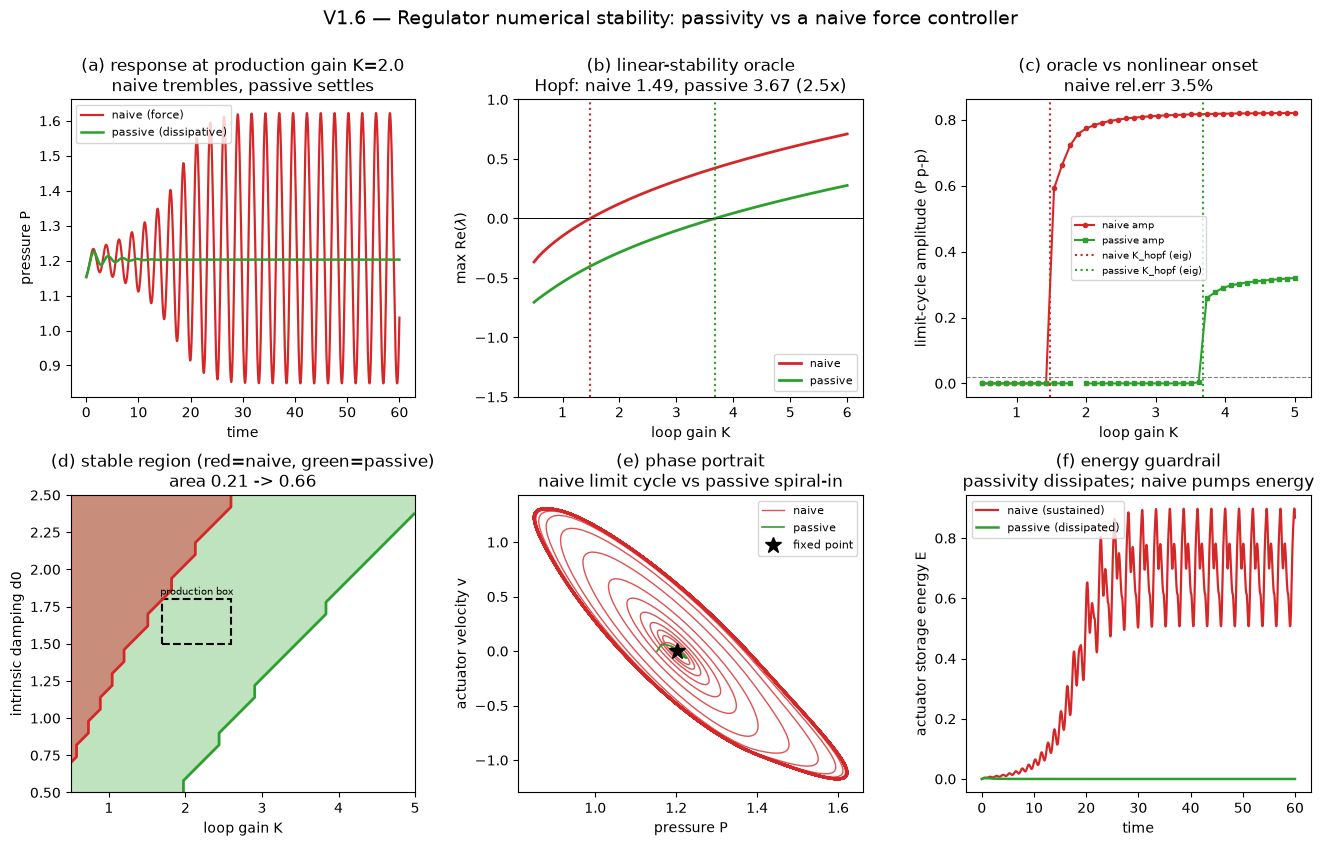

In [6]:
"""(6) Figure: time series, eigenvalues, amplitude-vs-gain, 2-D region, phase portrait, energy."""
fig = plt.figure(figsize=(16, 9))
gs = fig.add_gridspec(2, 3, hspace=0.33, wspace=0.30)

# (a) P(t) at the production gain: naive limit cycle vs passive settling
ax = fig.add_subplot(gs[0, 0])
ax.plot(sol_n.t, sol_n.y[0], "tab:red", lw=1.6, label="naive (force)")
ax.plot(sol_p.t, sol_p.y[0], "tab:green", lw=1.8, label="passive (dissipative)")
ax.set_xlabel("time"); ax.set_ylabel("pressure P")
ax.set_title(f"(a) response at production gain K={PROD_GAIN}\nnaive trembles, passive settles"); ax.legend(fontsize=8)

# (b) max Re(lambda) vs gain for both controllers, Hopf crossings
ax = fig.add_subplot(gs[0, 1])
mre_n = [rs.max_real_eig(sp, K, "naive") for K in K_EIG]
mre_p = [rs.max_real_eig(sp, K, "passive") for K in K_EIG]
ax.plot(K_EIG, mre_n, "tab:red", lw=2, label="naive")
ax.plot(K_EIG, mre_p, "tab:green", lw=2, label="passive")
ax.axhline(0, color="k", lw=0.7)
ax.axvline(kh_naive, color="tab:red", ls=":"); ax.axvline(kh_pass, color="tab:green", ls=":")
ax.set_ylim(-1.5, 1.0); ax.set_xlabel("loop gain K"); ax.set_ylabel("max Re($\\lambda$)")
ax.set_title(f"(b) linear-stability oracle\nHopf: naive {kh_naive:.2f}, passive {kh_pass:.2f} ({ratio:.1f}x)"); ax.legend(fontsize=8)

# (c) nonlinear limit-cycle amplitude vs gain + predicted Hopf onsets
ax = fig.add_subplot(gs[0, 2])
ax.plot(K_GRID, amp_naive, "o-", color="tab:red", ms=3, label="naive amp")
ax.plot(K_GRID, amp_pass, "s-", color="tab:green", ms=3, label="passive amp")
ax.axvline(kh_naive, color="tab:red", ls=":", label="naive K_hopf (eig)")
ax.axvline(kh_pass, color="tab:green", ls=":", label="passive K_hopf (eig)")
ax.axhline(AMP_FLOOR, color="0.5", ls="--", lw=0.8)
ax.set_xlabel("loop gain K"); ax.set_ylabel("limit-cycle amplitude (P p-p)")
ax.set_title(f"(c) oracle vs nonlinear onset\nnaive rel.err {oracle_err:.1%}"); ax.legend(fontsize=7)

# (d) 2-D stable region in (K, d0): passive (filled) contains naive (boundary), production box
ax = fig.add_subplot(gs[1, 0])
mask_n = rs.stable_region(sp, "naive", AREA_K, AREA_D)
mask_p = rs.stable_region(sp, "passive", AREA_K, AREA_D)
KK, DD = np.meshgrid(AREA_K, AREA_D)
ax.contourf(KK, DD, mask_p.astype(float), levels=[0.5, 1.5], colors=["tab:green"], alpha=0.3)
ax.contourf(KK, DD, mask_n.astype(float), levels=[0.5, 1.5], colors=["tab:red"], alpha=0.45)
ax.contour(KK, DD, mask_p.astype(float), levels=[0.5], colors="tab:green", linewidths=2)
ax.contour(KK, DD, mask_n.astype(float), levels=[0.5], colors="tab:red", linewidths=2)
ax.add_patch(plt.Rectangle((PROD_K[0], PROD_D[0]), PROD_K[-1]-PROD_K[0], PROD_D[-1]-PROD_D[0],
                           fill=False, edgecolor="k", lw=1.5, ls="--"))
ax.text(PROD_K.mean(), PROD_D[-1]+0.03, "production box", ha="center", fontsize=7)
ax.set_xlabel("loop gain K"); ax.set_ylabel("intrinsic damping d0")
ax.set_title(f"(d) stable region (red=naive, green=passive)\narea {area_naive:.2f} -> {area_pass:.2f}")

# (e) phase portrait (P, v): naive limit cycle vs passive spiral-in
ax = fig.add_subplot(gs[1, 1])
half = len(sol_n.t) // 2
ax.plot(sol_n.y[0], sol_n.y[2], "tab:red", lw=1.0, alpha=0.8, label="naive")
ax.plot(sol_n.y[0][half:], sol_n.y[2][half:], "tab:red", lw=2.0)         # the settled limit cycle
ax.plot(sol_p.y[0], sol_p.y[2], "tab:green", lw=1.2, label="passive")
Ph = rs.healthy_state(sp, PROD_GAIN)[0]
ax.plot([Ph], [0], "k*", ms=12, label="fixed point")
ax.set_xlabel("pressure P"); ax.set_ylabel("actuator velocity v")
ax.set_title("(e) phase portrait\nnaive limit cycle vs passive spiral-in"); ax.legend(fontsize=8)

# (f) actuator storage energy vs time
ax = fig.add_subplot(gs[1, 2])
ax.plot(sol_n.t, E_n, "tab:red", lw=1.6, label="naive (sustained)")
ax.plot(sol_p.t, E_p, "tab:green", lw=1.8, label="passive (dissipated)")
ax.set_xlabel("time"); ax.set_ylabel("actuator storage energy E")
ax.set_title("(f) energy guardrail\npassivity dissipates; naive pumps energy"); ax.legend(fontsize=8)

fig.suptitle("V1.6 — Regulator numerical stability: passivity vs a naive force controller", fontsize=14, y=0.98)
OUT = RESULTS / "V1_6_regulator_stability.png"
fig.savefig(OUT, dpi=110, bbox_inches="tight")
print(f"saved {OUT}")
plt.show()

In [7]:
"""(7) Frozen verdict."""
def verdict(name, passed, detail, outcome):
    print(f"  [{'OK ' if passed else 'XX '}] {name:32s} {'PASS' if passed else f'FAIL -> {outcome}'}")
    print(f"        {detail}")

print("=" * 84)
print("V1.6 — REGULATOR NUMERICAL STABILITY (NO SPURIOUS LIMIT CYCLES) — VERDICT")
print("=" * 84)
verdict("A. linear-stability oracle", A_PASS,
        f"eigenvalue Hopf gain {kh_naive:.3f} matches nonlinear onset {onset_naive:.3f} "
        f"(rel.err {oracle_err:.1%} <= {ORACLE_TOL:.0%})", "CONSTRAIN (use nonlinear onset)")
verdict("B. passive region strictly larger", B_PASS,
        f"K_hopf passive/naive = {ratio:.2f}x (>= {KHOPF_RATIO_MIN}); 2-D area {area_naive:.2f} -> {area_pass:.2f}",
        "CONSTRAIN")
verdict("C. production envelope clean", C_PASS,
        f"passive 0/{n_box} oscillate; naive {naive_osc}/{n_box} tremble (hazard real)",
        "CONSTRAIN (publish gain bounds)")
verdict("D. energy/passivity", D_PASS,
        f"storage energy decays under passivity ({E_p[-300:].mean():.1e}), sustained under naive "
        f"({E_n[-300:].mean():.2f})", "diagnostic")

ALL_PASS = A_PASS and B_PASS and C_PASS and D_PASS
print("=" * 84)
if ALL_PASS:
    print("  V1.6 OVERALL: PASS - the passivity / energy formulation has a strictly larger oscillation-")
    print("                free gain region; the linear-stability oracle predicts the limit-cycle onset;")
    print("                and within the production envelope the regulated creature does not tremble,")
    print("                while a naive force controller would. The energy guardrail is load-bearing.")
    print("  -> V1.5 + V1.6 both PASS: architecture Phase 2 (living things) is UNBLOCKED (protocol section 9).")
else:
    print("  V1.6 OVERALL: FAIL - see outcome class above.")
print("=" * 84)
assert ALL_PASS, "V1.6 did not pass - see verdict above."

V1.6 — REGULATOR NUMERICAL STABILITY (NO SPURIOUS LIMIT CYCLES) — VERDICT
  [OK ] A. linear-stability oracle       PASS
        eigenvalue Hopf gain 1.487 matches nonlinear onset 1.538 (rel.err 3.5% <= 10%)
  [OK ] B. passive region strictly larger PASS
        K_hopf passive/naive = 2.47x (>= 2.0); 2-D area 0.21 -> 0.66
  [OK ] C. production envelope clean     PASS
        passive 0/28 oscillate; naive 28/28 tremble (hazard real)
  [OK ] D. energy/passivity              PASS
        storage energy decays under passivity (8.4e-16), sustained under naive (0.70)
  V1.6 OVERALL: PASS - the passivity / energy formulation has a strictly larger oscillation-
                free gain region; the linear-stability oracle predicts the limit-cycle onset;
                and within the production envelope the regulated creature does not tremble,
                while a naive force controller would. The energy guardrail is load-bearing.
  -> V1.5 + V1.6 both PASS: architecture Phase 2 (living thing